In [102]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [123]:
df = pd.read_csv("student_performance_new.csv")

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_ID               700000 non-null  int64  
 1   student_id               700000 non-null  int64  
 2   weekly_self_study_hours  700000 non-null  float64
 3   attendance_percentage    700000 non-null  float64
 4   class_participation      700000 non-null  float64
 5   total_score              700000 non-null  float64
 6   grade                    700000 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 37.4 MB


In [132]:
df.describe()
#上位25%以上が100点を取れており、上位50%以上が87点以上取れている。また全体の半分がA評価を受けている。

,student_ID,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,350000.500000,500055.726204,15.028228,84.712100,5.986648,84.273773,3.297596
std,202072.738554,288517.382442,6.900236,9.419874,1.956111,15.433573,0.915195
min,1.000000,1.000000,0.000000,50.000000,0.000000,9.400000,0.000000
25%,175000.750000,250265.750000,10.300000,78.300000,4.700000,73.900000,3.000000
50%,350000.500000,500015.500000,15.000000,85.000000,6.000000,87.500000,4.000000
75%,525000.250000,749796.250000,19.700000,91.700000,7.300000,100.000000,4.000000
max,700000.000000,1000000.000000,40.000000,100.000000,10.000000,100.000000,4.000000


In [127]:
df["grade"] = df["grade"].astype(str).str.strip().str.upper() #stripで空白を削除し、upperで大文字に変換

grade_map = {"A":4, "B":3, "C":2, "D":1, "F":0} #E評価は無いので、そのまま上から順に数値化
df["grade"] = df["grade"].map(grade_map)

In [128]:
df["grade"] = df["grade"].astype("float") #このままだとobject型になってしまうため、float型に変換
df["total_score"] = df["total_score"].astype("float")


In [133]:
df.corr()
#「学習時間」と「点数および成績」に相関ありそう。他はほとんど相関なし。

,student_ID,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
student_ID,1.000000,-0.000217,-0.000073,0.000012,0.003419,-0.002011,-0.001944
student_id,-0.000217,1.000000,-0.001479,-0.001020,0.002052,0.000111,0.000403
weekly_self_study_hours,-0.000073,-0.001479,1.000000,-0.001222,0.001454,0.812299,0.742906
attendance_percentage,0.000012,-0.001020,-0.001222,1.000000,0.000208,-0.001420,-0.001684
class_participation,0.003419,0.002052,0.001454,0.000208,1.000000,0.000342,0.000647
total_score,-0.002011,0.000111,0.812299,-0.001420,0.000342,1.000000,0.951738
grade,-0.001944,0.000403,0.742906,-0.001684,0.000647,0.951738,1.000000


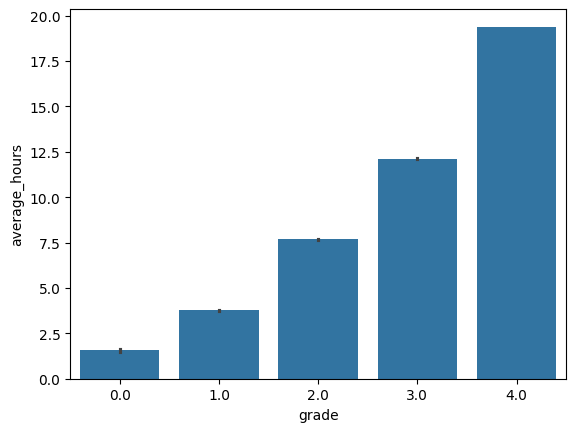

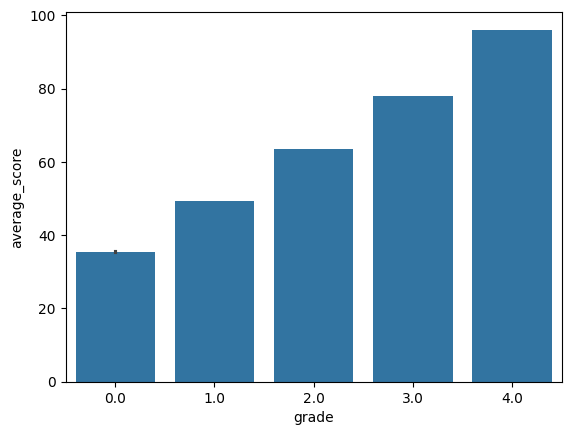

In [134]:
score_df = df.groupby("grade")["weekly_self_study_hours"].mean().reset_index()
sns.barplot(x="grade", y="weekly_self_study_hours", data=df)
plt.ylabel("average_hours")
plt.show()
#評価が高くなるほど、平均学習時間も増加している

score_df = df.groupby("grade")["total_score"].mean().reset_index()
sns.barplot(x="grade", y="total_score", data=df)
plt.ylabel("average_score")
plt.show()

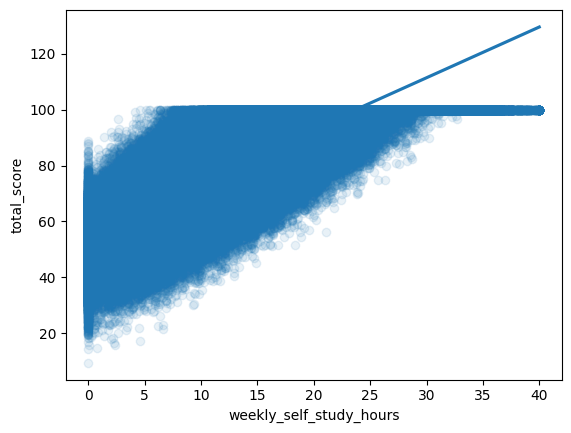

In [135]:
sns.regplot(x="weekly_self_study_hours", y="total_score", data=df, scatter_kws={"alpha": 0.1})
plt.show()
#散布図でも、学習時間が増えるほど得点が上がる傾向が見て取れる。

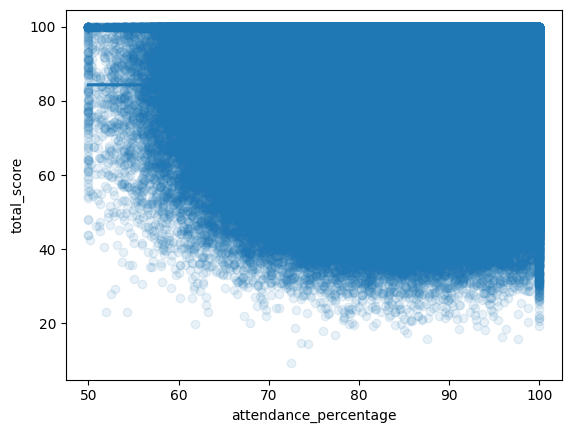

In [136]:
sns.regplot(x="attendance_percentage", y="total_score", data=df, scatter_kws={"alpha": 0.1})
plt.show()
#授業の出席率は得点に大きな影響は与えない。100％の出席率でも30点台・40点台が多く、100点獲得者でも出席率が低い生徒が多くいる。

In [137]:
fig = px.histogram(df, x="grade", nbins=5)
fig.show()
#全体の半数がA評価（4点)ということが、図からも見て取れる。

fig = px.histogram(df, x="total_score", nbins=30)
fig.show()
#100点獲得者がずば抜けて多い。次のボリュームゾーンは80点台。

In [138]:
correlation_matrix = df.corr()
fig = px.imshow(correlation_matrix, text_auto=True, color_continuous_scale="RdBu_r")
fig.update_layout(width=800,height=800)
fig.show()
#得点と成績に強い相関が出ているが、点数が高いと成績が良いのは当たり前のことなので今回は扱わない。

In [139]:
import statsmodels.api as sm

x = df[["weekly_self_study_hours", "attendance_percentage", "class_participation"]]
y = df["total_score"]

x = sm.add_constant(x)

model = sm.OLS(y, x).fit()

print(model.summary())

#R値（決定係数）が1に近ければ近いほど「よく説明できている」と判断できる。
#coef：各説明変数の係数。
#p値：0.05未満なら有意。

                            OLS Regression Results                            
Dep. Variable:            total_score   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                 4.526e+05
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:30:36   Log-Likelihood:            -2.5314e+06
No. Observations:              700000   AIC:                         5.063e+06
Df Residuals:                  699996   BIC:                         5.063e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     